Importing Libraries and Loading Dataset

In [1]:
import numpy as np 
import pandas as pd

df = pd.read_csv(r"E:\Customer Churn Prediction Project\Churn_Modelling.csv")
display(df.head())
df.shape

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


(10000, 14)

Checking Null Values and Duplicated rows in the dataset

In [2]:
df.info()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


np.int64(0)

Checking how many customers leaved the bank and how many Still are there

In [3]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

Checking The Customers Where are they From and Whetherthey are male or female

In [4]:
print(df["Geography"].value_counts())

print(df["Gender"].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64


Removing Unnecessary Columns

In [5]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace = True)

In [6]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


EDA Exploratory Data Analysis

Visualizations

Target Variable

C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\92448426.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\92448426.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])


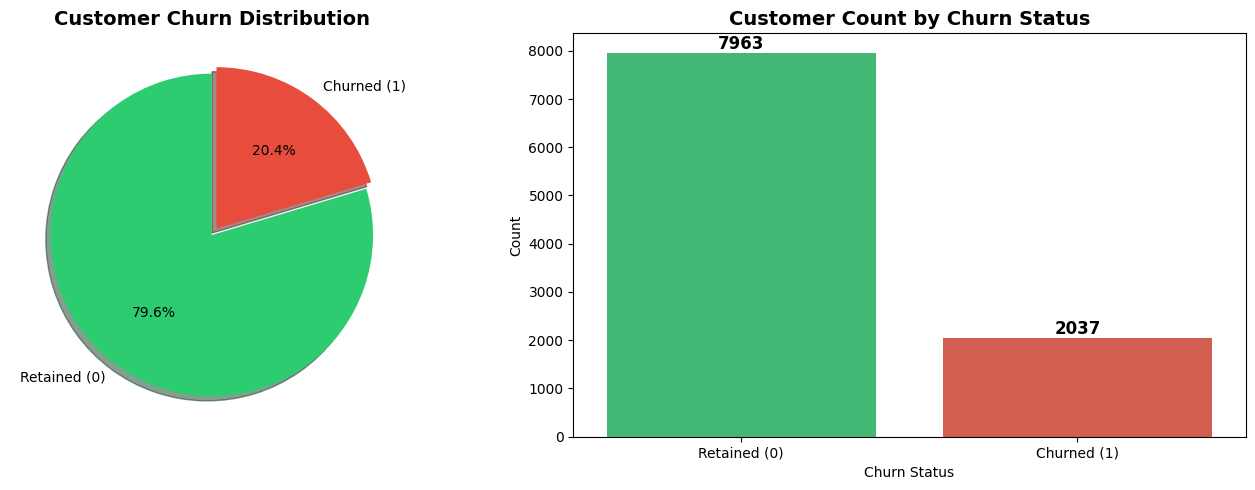

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CHURN DISTRIBUTION - PIE + BAR
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(df['Exited'].value_counts(), 
            labels=['Retained (0)', 'Churned (1)'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.05),
            shadow=True,
            startangle=90)
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df, x='Exited', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[1].set_title('Customer Count by Churn Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Count')

# Add counts on bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()



Numerical Feature Analysis

In [8]:
num_of_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember']

print("Numerical Features Stats By Churn")

for col in num_of_columns:
    print(f"\n---{col}---")
    print(df.groupby('Exited')[col].describe())

Numerical Features Stats By Churn

---CreditScore---
         count        mean         std    min    25%    50%    75%    max
Exited                                                                   
0       7963.0  651.853196   95.653837  405.0  585.0  653.0  718.0  850.0
1       2037.0  645.351497  100.321503  350.0  578.0  646.0  716.0  850.0

---Age---
         count       mean        std   min   25%   50%   75%   max
Exited                                                            
0       7963.0  37.408389  10.125363  18.0  31.0  36.0  41.0  92.0
1       2037.0  44.837997   9.761562  18.0  38.0  45.0  51.0  84.0

---Tenure---
         count      mean       std  min  25%  50%  75%   max
Exited                                                      
0       7963.0  5.033279  2.880658  0.0  3.0  5.0  7.0  10.0
1       2037.0  4.932744  2.936106  0.0  2.0  5.0  8.0  10.0

---Balance---
         count          mean           std  min       25%        50%  \
Exited                     

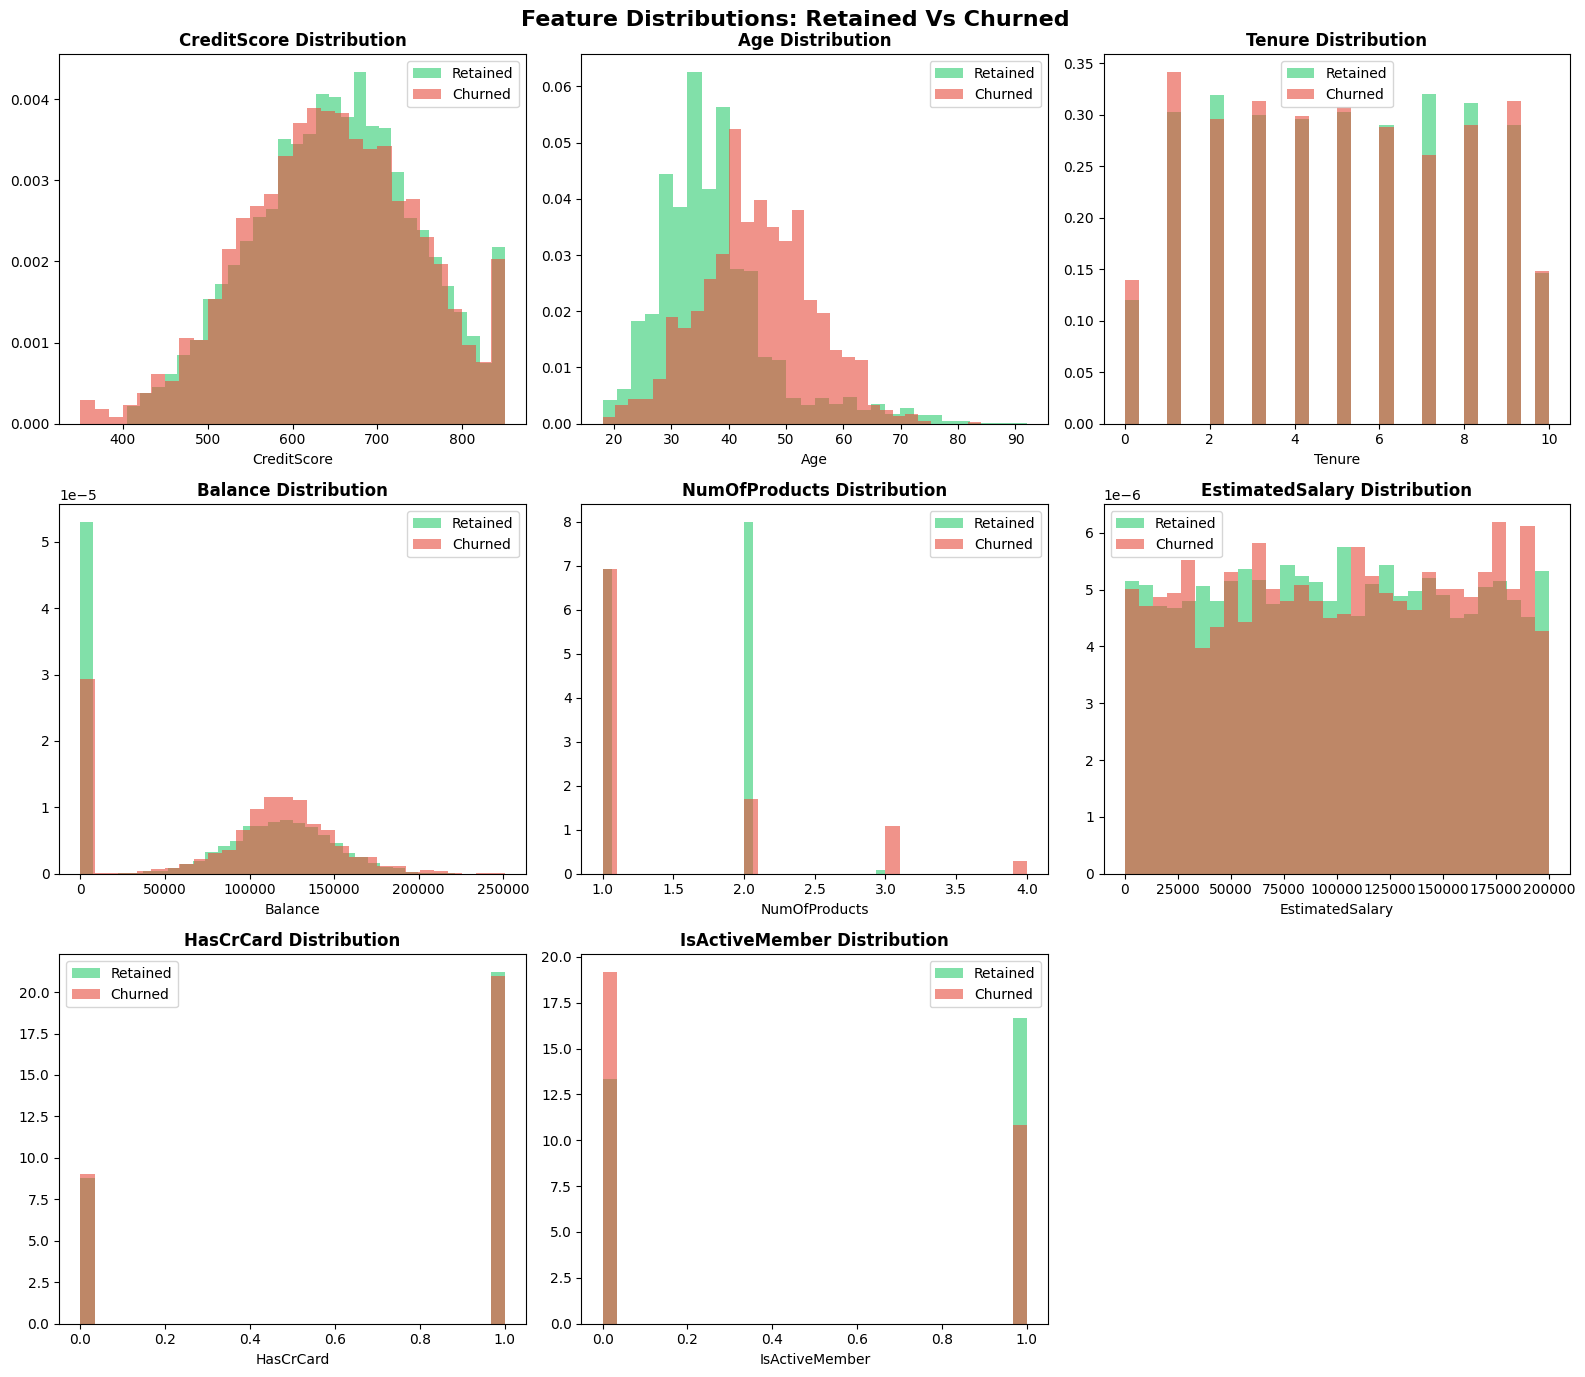

In [9]:
#Visualizing Numerical Features By Histogram
fig, axes = plt.subplots(3, 3, figsize=(16,14))
axes = axes.flatten()

for i, col in enumerate(num_of_columns):
    #Retained
    axes[i].hist(df[df['Exited']==0][col], bins= 30, alpha = 0.6, color = '#2ecc71', label='Retained', density = True)

    #Churned
    axes[i].hist(df[df['Exited']==1][col], bins = 30, alpha = 0.6, color = '#e74c3c', label='Churned', density = True)

    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(col)


#Hide Extra
axes[8].axis('off')

plt.suptitle("Feature Distributions: Retained Vs Churned", fontsize=16, fontweight= 'bold', y=0.98)
plt.tight_layout()
plt.show()

Box Plots For Compring Churn vs No Churn

C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\1822565655.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df, x='Exited', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\1822565655.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Retained', 'Churned'])
C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\1822565655.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df, x='Exited', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_

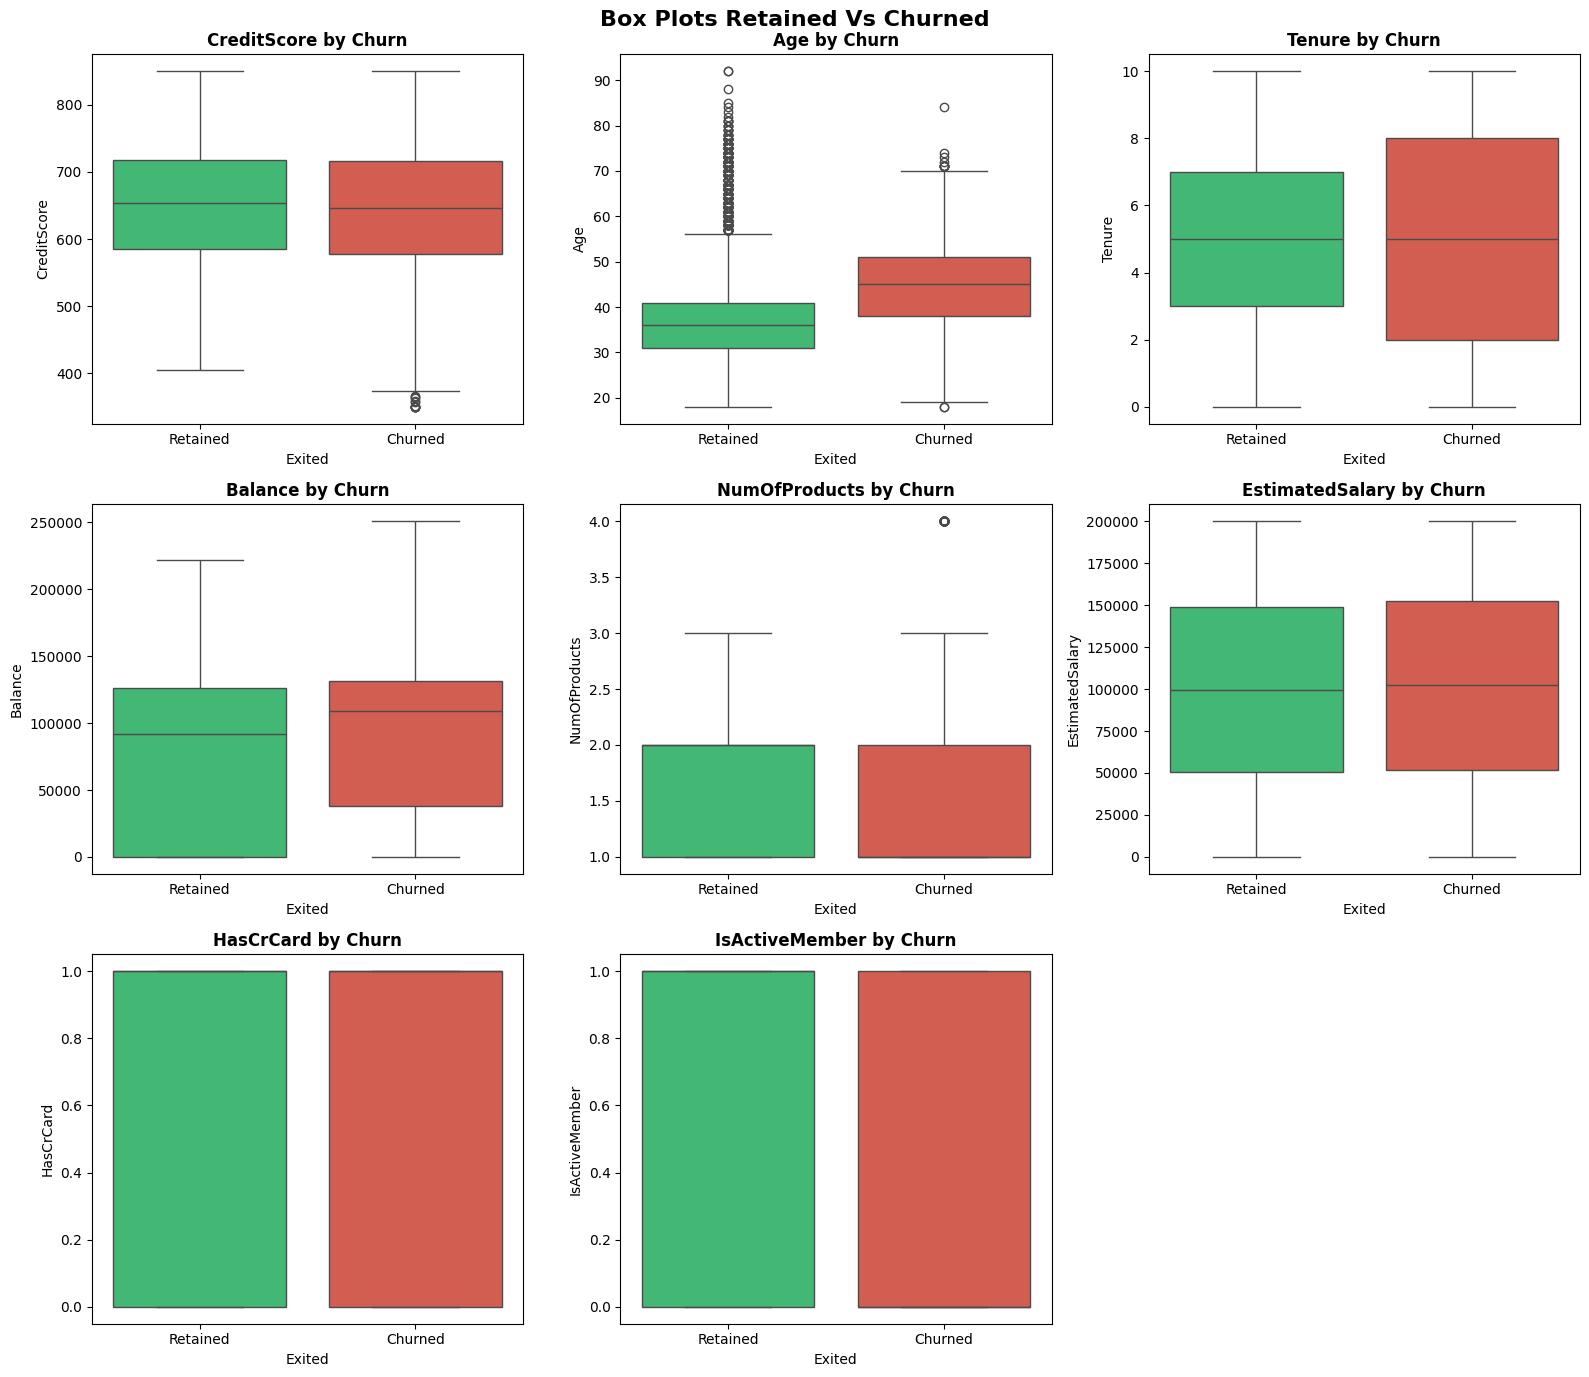

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_of_columns):
    sns.boxplot(data= df, x='Exited', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} by Churn', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['Retained', 'Churned'])

axes[8].axis('off') 

plt.suptitle("Box Plots Retained Vs Churned", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Key Insights - Age

Age Analysis

C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\1460767257.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100


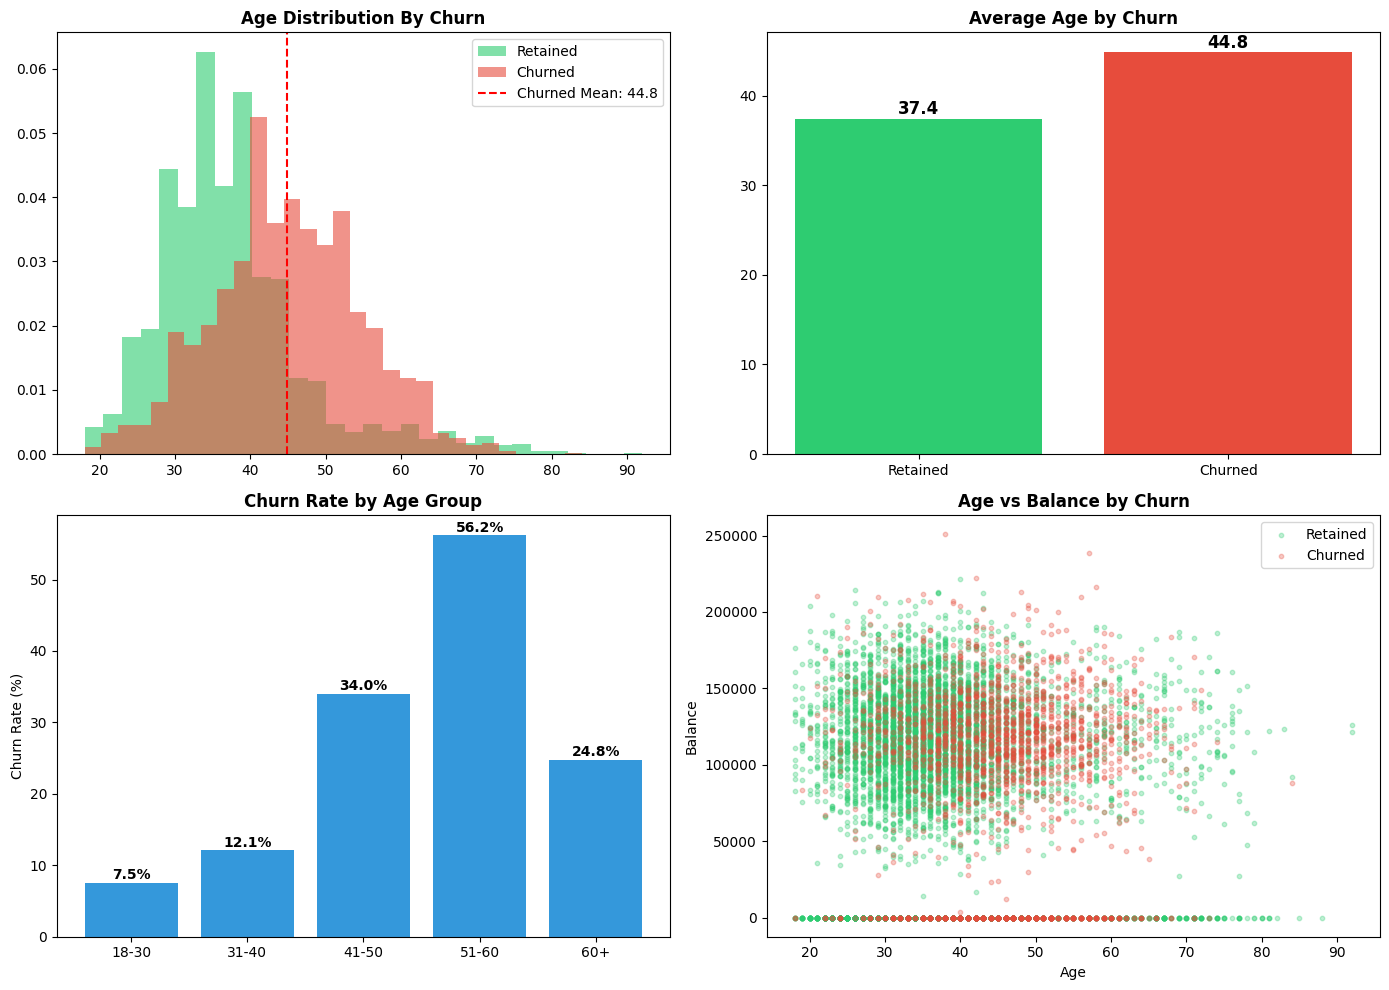


=== KEY INSIGHT: AGE ===
Average Age (Retained): 37.4
Average Age (Churned):  44.8
Difference: 7.4 years


In [11]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CHART 1: Age Distribution By Churn (Histogram)
axes[0, 0].hist(df[df['Exited']==0]['Age'], bins=30, alpha=0.6, color='#2ecc71', label='Retained', density=True)
axes[0, 0].hist(df[df['Exited']==1]['Age'], bins=30, alpha=0.6, color='#e74c3c', label='Churned', density=True)

axes[0, 0].set_title("Age Distribution By Churn", fontweight='bold')
axes[0, 0].axvline(df[df['Exited']==1]['Age'].mean(), color='red', linestyle='--', 
                   label=f"Churned Mean: {df[df['Exited']==1]['Age'].mean():.1f}")

axes[0, 0].legend()  

# CHART 2: Average Age by Churn (Bar Chart) 
age_mean = df.groupby('Exited')['Age'].mean() 

axes[0, 1].bar(['Retained', 'Churned'], age_mean.values, color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Average Age by Churn', fontweight='bold')

# 🛠️ .values lagao loop mein bhi
for i, v in enumerate(age_mean.values):
    axes[0, 1].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold', fontsize=12)

# CHART 3: Churn Rate by Age Group (Bar Chart)
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 30, 40, 50, 60, 100], 
                        labels=['18-30', '31-40', '41-50', '51-60', '60+'])

age_churn = df.groupby('AgeGroup')['Exited'].mean() * 100
axes[1, 0].bar(age_churn.index.astype(str), age_churn.values, color='#3498db')
axes[1, 0].set_title('Churn Rate by Age Group', fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')

for i, v in enumerate(age_churn.values):
    axes[1, 0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# CHART 4: Age vs Balance Colored by Churn (Scatter Plot)
axes[1, 1].scatter(df[df['Exited']==0]['Age'], df[df['Exited']==0]['Balance'], 
                   alpha=0.3, s=10, color='#2ecc71', label='Retained')

axes[1, 1].scatter(df[df['Exited']==1]['Age'], df[df['Exited']==1]['Balance'], 
                   alpha=0.3, s=10, color='#e74c3c', label='Churned')

axes[1, 1].set_title('Age vs Balance by Churn', fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Balance')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# PRINT INSIGHTS
print(f"\n=== KEY INSIGHT: AGE ===")
print(f"Average Age (Retained): {df[df['Exited']==0]['Age'].mean():.1f}")
print(f"Average Age (Churned):  {df[df['Exited']==1]['Age'].mean():.1f}")
print(f"Difference: {df[df['Exited']==1]['Age'].mean() - df[df['Exited']==0]['Age'].mean():.1f} years")

# ==========================================
# CLEAN UP
# ==========================================
df = df.drop('AgeGroup', axis=1)

Categorical features

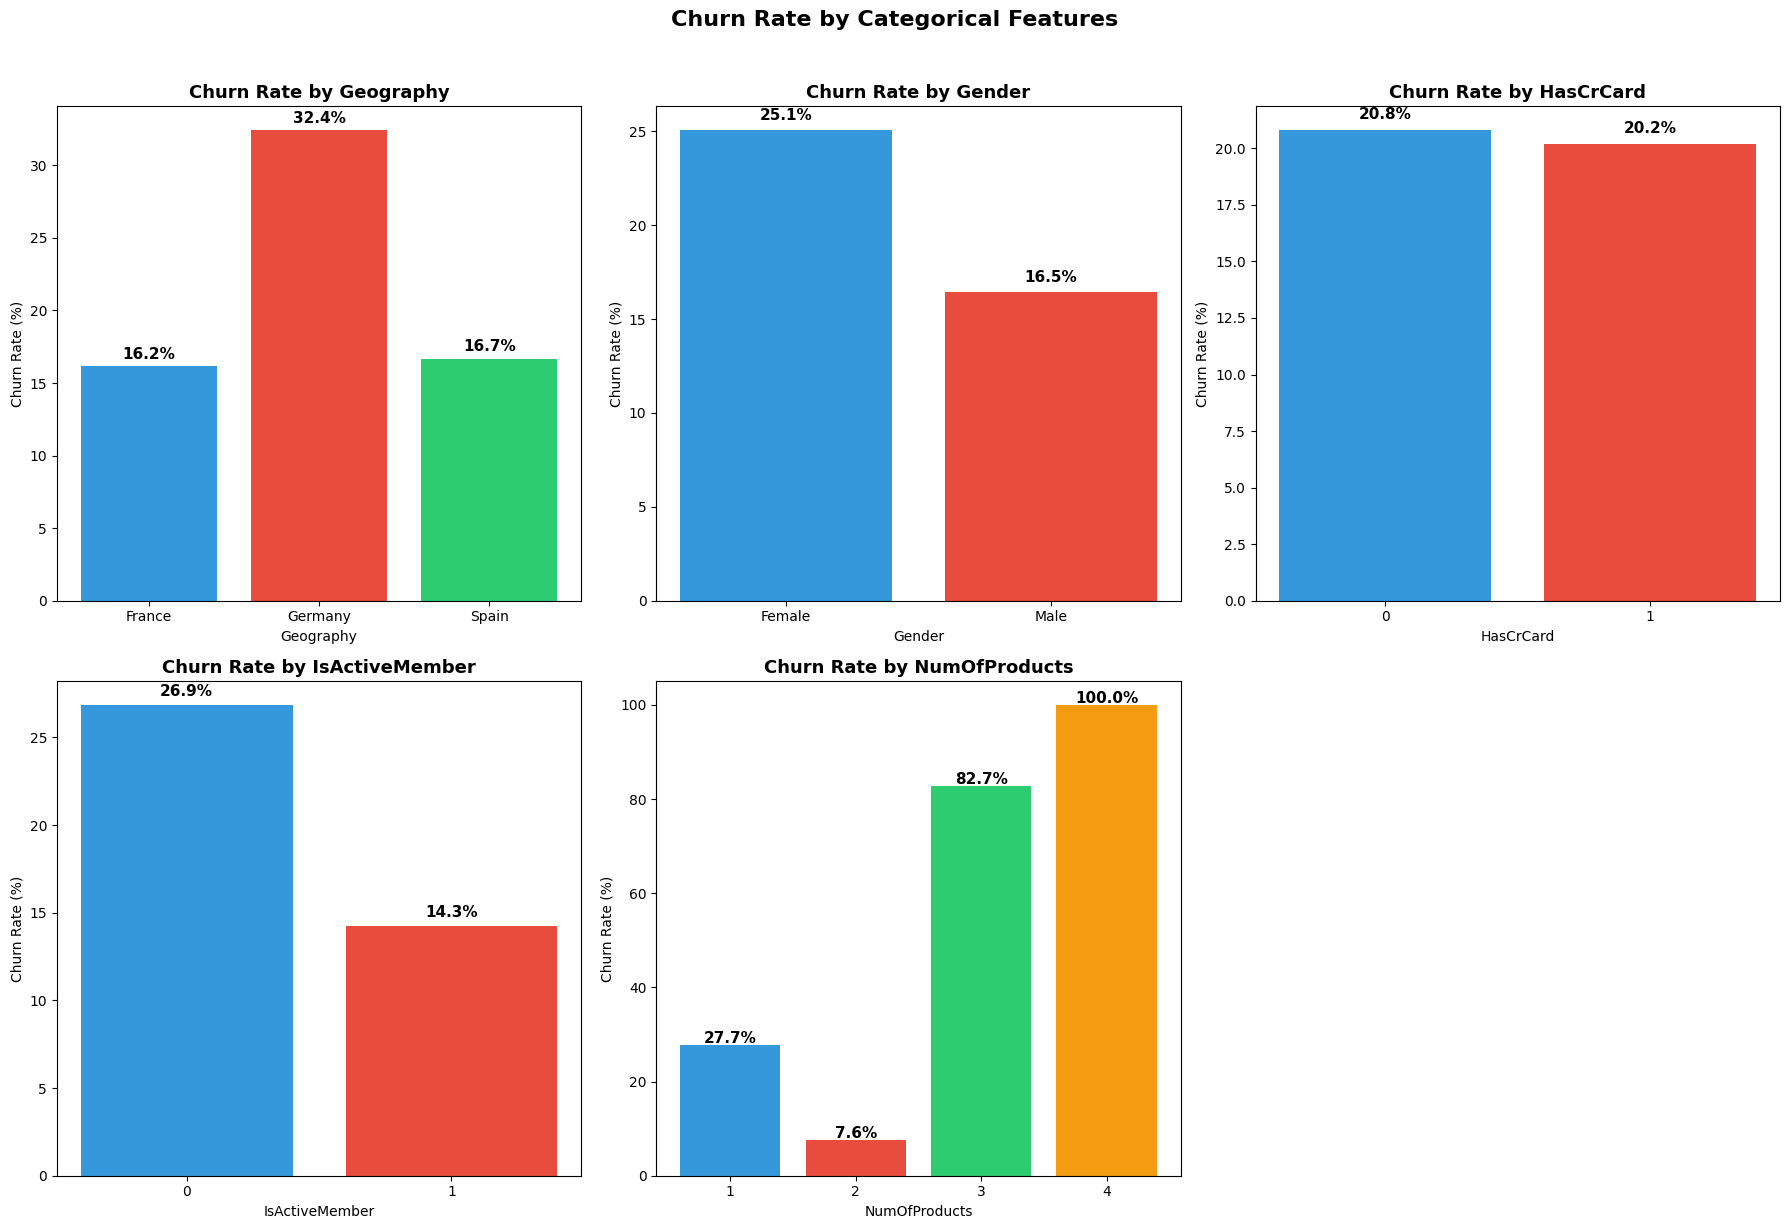

In [12]:
# CATEGORICAL COLUMNS
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Churn rate by category
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    
    # Bar plot
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values, 
                       color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'][:len(churn_rate)])
    axes[i].set_title(f'Churn Rate by {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel(col)
    
    # Add percentage labels
    for bar, v in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                     f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

axes[5].axis('off')

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

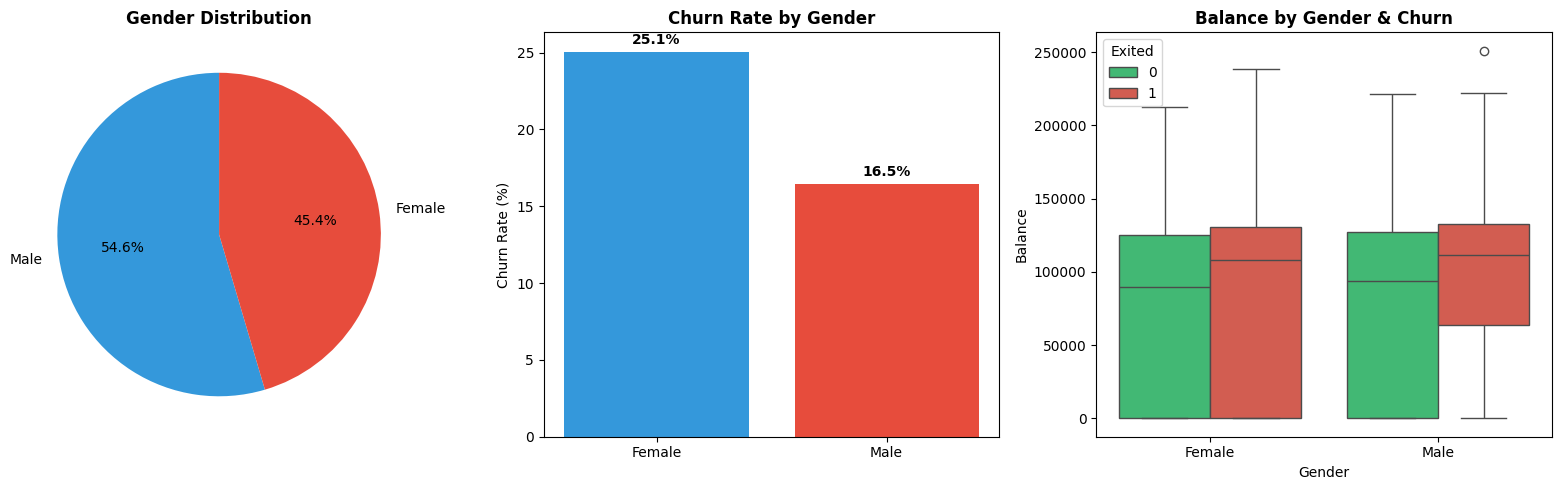

In [13]:
# DETAILED: GENDER ANALYSIS
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Count
gender_count = df['Gender'].value_counts()
axes[0].pie(gender_count, labels=gender_count.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90)
axes[0].set_title('Gender Distribution', fontweight='bold')

# Churn rate
gender_churn = df.groupby('Gender')['Exited'].mean() * 100
axes[1].bar(gender_churn.index, gender_churn.values, color=['#3498db', '#e74c3c'])
axes[1].set_title('Churn Rate by Gender', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(gender_churn.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Gender vs Balance by Churn
sns.boxplot(data=df, x='Gender', y='Balance', hue='Exited', ax=axes[2],
            palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('Balance by Gender & Churn', fontweight='bold')

plt.tight_layout()
plt.show()

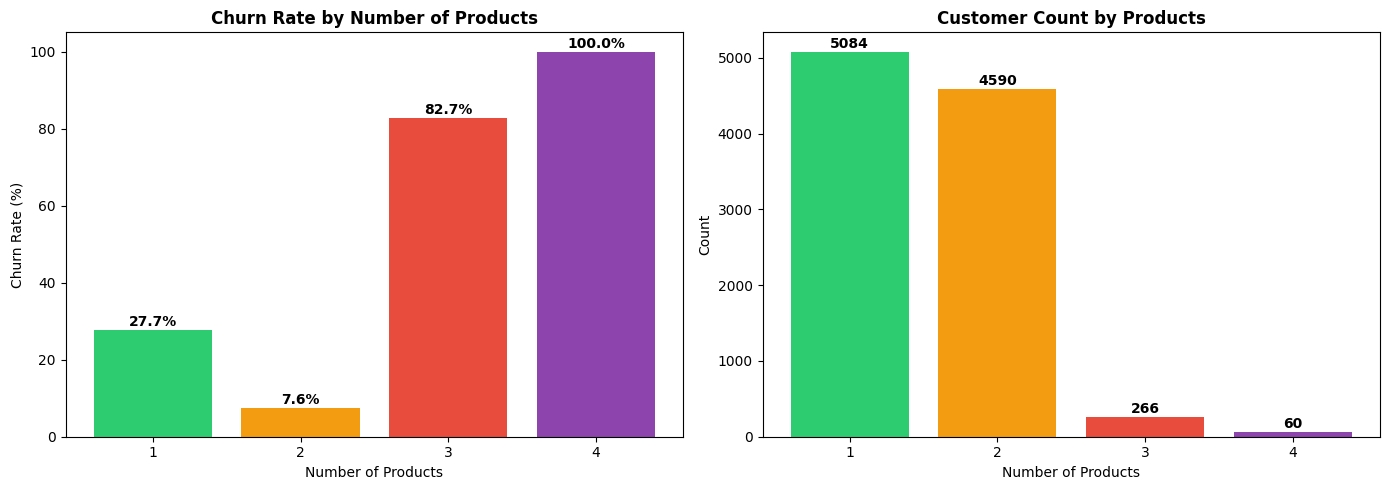


=== PRODUCT ANALYSIS ===
               count   sum      mean
NumOfProducts                       
1               5084  1409  0.277144
2               4590   348  0.075817
3                266   220  0.827068
4                 60    60  1.000000

 Key Insight: Customers with 3–4 products have a significantly higher churn rate.
This is counter-intuitive — having more products actually leads to higher churn.


In [14]:
# DETAILED: NUMBER OF PRODUCTS (CRITICAL INSIGHT)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
axes[0].bar(prod_churn.index.astype(str), prod_churn.values, 
            color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'])
axes[0].set_title('Churn Rate by Number of Products', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Number of Products')
for i, v in enumerate(prod_churn.values):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# Count by products
prod_count = df['NumOfProducts'].value_counts().sort_index()
axes[1].bar(prod_count.index.astype(str), prod_count.values, 
            color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'])
axes[1].set_title('Customer Count by Products', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Number of Products')
for i, v in enumerate(prod_count.values):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== PRODUCT ANALYSIS ===")
print(df.groupby('NumOfProducts')['Exited'].agg(['count', 'sum', 'mean']))
print("\n Key Insight: Customers with 3–4 products have a significantly higher churn rate.")
print("This is counter-intuitive — having more products actually leads to higher churn.")



Active Member Analysis

C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\2553694237.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Inactive', 'Active'])
C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\2553694237.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Inactive', 'Active'])


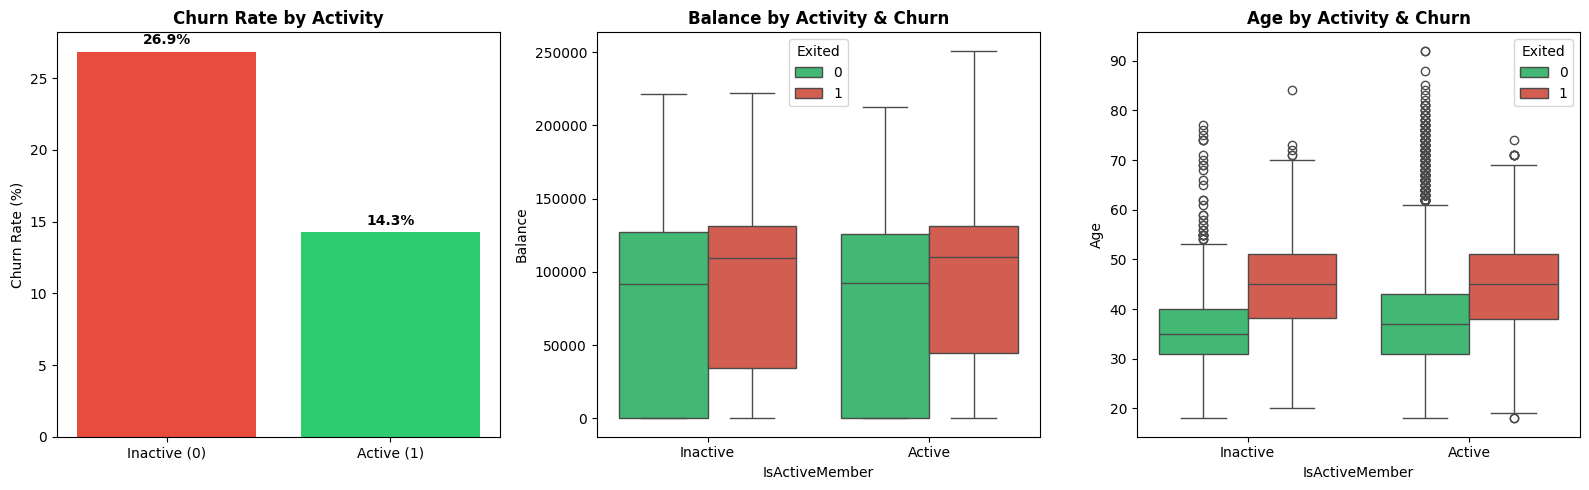


=== ACTIVITY IMPACT ===
Inactive Churn Rate: 26.9%
Active Churn Rate:   14.3%
Difference:          12.6% points


In [15]:
# IS ACTIVE MEMBER ANALYSIS
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn rate
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
axes[0].bar(['Inactive (0)', 'Active (1)'], active_churn.values, 
            color=['#e74c3c', '#2ecc71'])

axes[0].set_title('Churn Rate by Activity', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')

for i, v in enumerate(active_churn.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Activity vs Balance
sns.boxplot(data=df, x='IsActiveMember', y='Balance', hue='Exited', ax=axes[1],
            palette=['#2ecc71', '#e74c3c'])

axes[1].set_title('Balance by Activity & Churn', fontweight='bold')
axes[1].set_xticklabels(['Inactive', 'Active'])

# Activity vs Age
sns.boxplot(data=df, x='IsActiveMember', y='Age', hue='Exited', ax=axes[2],
            palette=['#2ecc71', '#e74c3c'])

axes[2].set_title('Age by Activity & Churn', fontweight='bold')
axes[2].set_xticklabels(['Inactive', 'Active'])

plt.tight_layout()
plt.show()

print("\n=== ACTIVITY IMPACT ===")
print(f"Inactive Churn Rate: {active_churn[0]:.1f}%")
print(f"Active Churn Rate:   {active_churn[1]:.1f}%")
print(f"Difference:          {active_churn[0] - active_churn[1]:.1f}% points")

Balance Analysis

C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\2857844041.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bal_q_churn = df.groupby('BalanceGroup')['Exited'].mean() * 100


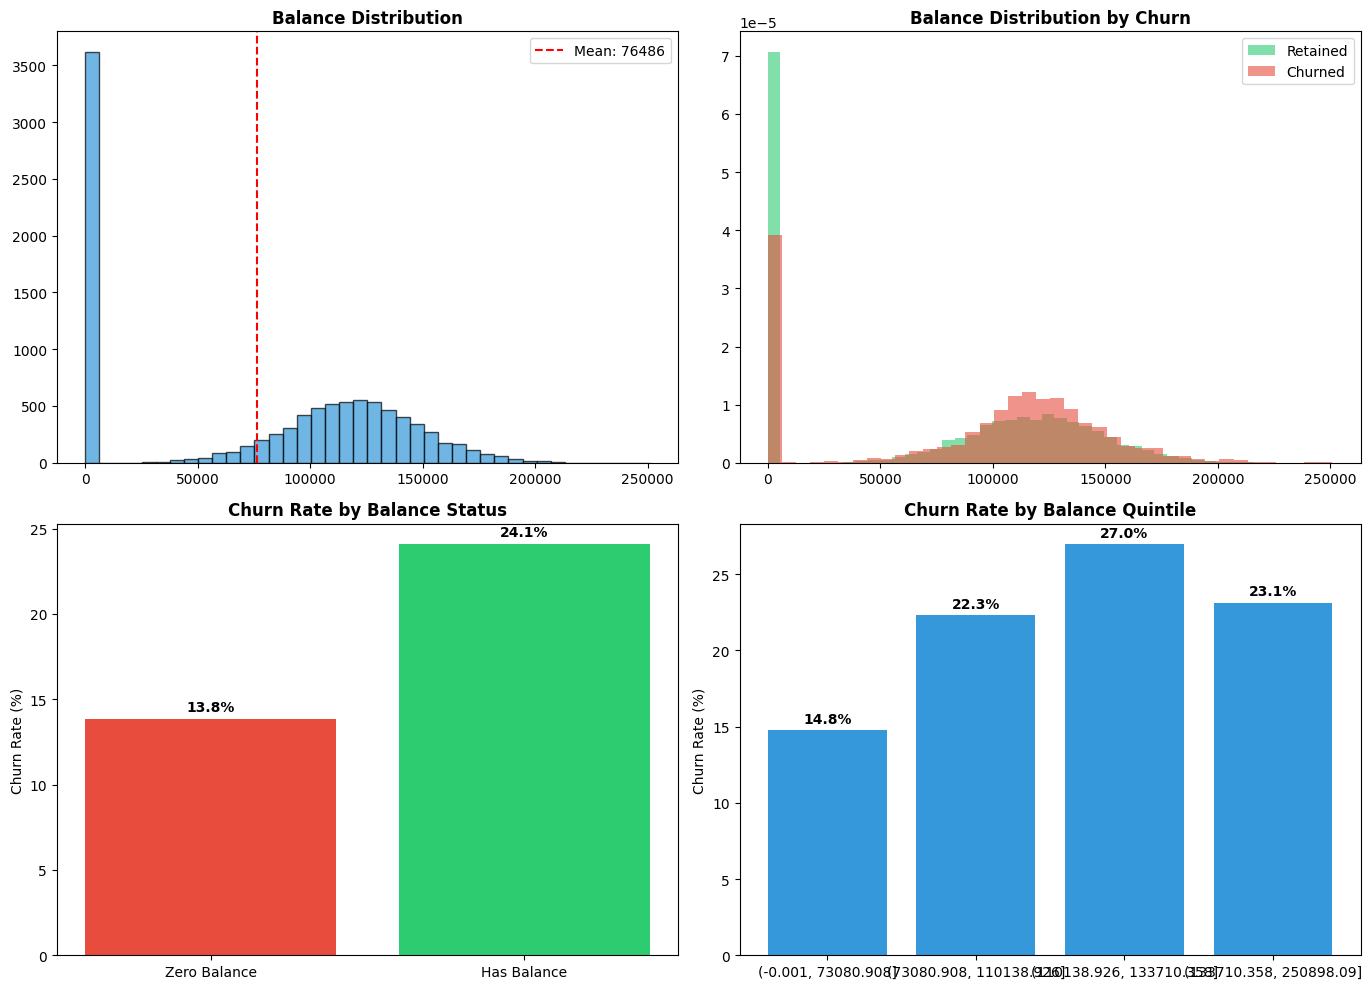


=== BALANCE STATS ===
Zero Balance Customers: 3617 (36.2%)
Non-Zero Balance Customers: 6383 (63.8%)


In [16]:
# BALANCE ANALYSIS
# ============================================================
# ✅ SAFE SIDE: Balance ko number mein badlo (agar koi text ho toh)
df['Balance'] = pd.to_numeric(df['Balance'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Balance distribution
axes[0,0].hist(df['Balance'], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['Balance'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {df['Balance'].mean():.0f}")

axes[0,0].set_title('Balance Distribution', fontweight='bold')
axes[0,0].legend()

# Balance by churn
axes[0,1].hist(df[df['Exited']==0]['Balance'], bins=40, alpha=0.6, 
               color='#2ecc71', label='Retained', density=True)

axes[0,1].hist(df[df['Exited']==1]['Balance'], bins=40, alpha=0.6, 
               color='#e74c3c', label='Churned', density=True)

axes[0,1].set_title('Balance Distribution by Churn', fontweight='bold')
axes[0,1].legend()

# Zero balance analysis
# 🛠️ FIX 1: astype(1) ki jagah astype(int) likho
df['HasBalance'] = (df['Balance'] > 0).astype(int)
bal_churn = df.groupby('HasBalance')['Exited'].mean() * 100

axes[1,0].bar(['Zero Balance', 'Has Balance'], bal_churn.values, 
              color=['#e74c3c', '#2ecc71'])

axes[1,0].set_title('Churn Rate by Balance Status', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')

for i, v in enumerate(bal_churn.values):
    axes[1,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Balance quantiles
# 🛠️ FIX 2: labels hata diye taake agar groups kam ho jayein toh error na aaye
df['BalanceGroup'] = pd.qcut(df['Balance'], q=5, duplicates='drop')

bal_q_churn = df.groupby('BalanceGroup')['Exited'].mean() * 100
axes[1,1].bar(bal_q_churn.index.astype(str), bal_q_churn.values, color='#3498db')
axes[1,1].set_title('Churn Rate by Balance Quintile', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate (%)')

for i, v in enumerate(bal_q_churn.values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Cleanup temp columns
df = df.drop(['HasBalance', 'BalanceGroup'], axis=1)

print(f"\n=== BALANCE STATS ===")
print(f"Zero Balance Customers: {(df['Balance']==0).sum()} ({(df['Balance']==0).mean()*100:.1f}%)")
print(f"Non-Zero Balance Customers: {(df['Balance']>0).sum()} ({(df['Balance']>0).mean()*100:.1f}%)")

Credit Score Analysis

C:\Users\Shahzain Ahmed\AppData\Local\Temp\ipykernel_18896\3276498246.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_churn = df.groupby('CreditGroup')['Exited'].mean() * 100


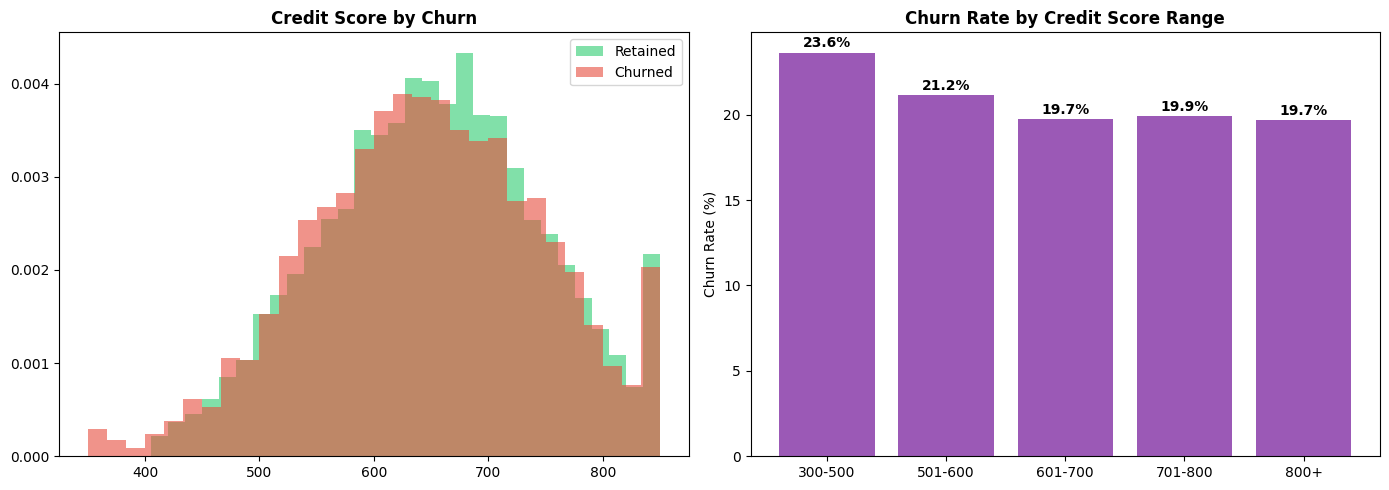

In [17]:
# CREDIT SCORE ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by churn
axes[0].hist(df[df['Exited']==0]['CreditScore'], bins=30, alpha=0.6, 
             color='#2ecc71', label='Retained', density=True)
axes[0].hist(df[df['Exited']==1]['CreditScore'], bins=30, alpha=0.6, 
             color='#e74c3c', label='Churned', density=True)
axes[0].set_title('Credit Score by Churn', fontweight='bold')
axes[0].legend()

# Credit score groups
df['CreditGroup'] = pd.cut(df['CreditScore'], bins=[300, 500, 600, 700, 800, 900], 
                            labels=['300-500', '501-600', '601-700', '701-800', '800+'])
credit_churn = df.groupby('CreditGroup')['Exited'].mean() * 100
axes[1].bar(credit_churn.index.astype(str), credit_churn.values, color='#9b59b6')
axes[1].set_title('Churn Rate by Credit Score Range', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(credit_churn.values):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Cleanup
df = df.drop('CreditGroup', axis=1)



Correlation Matrix

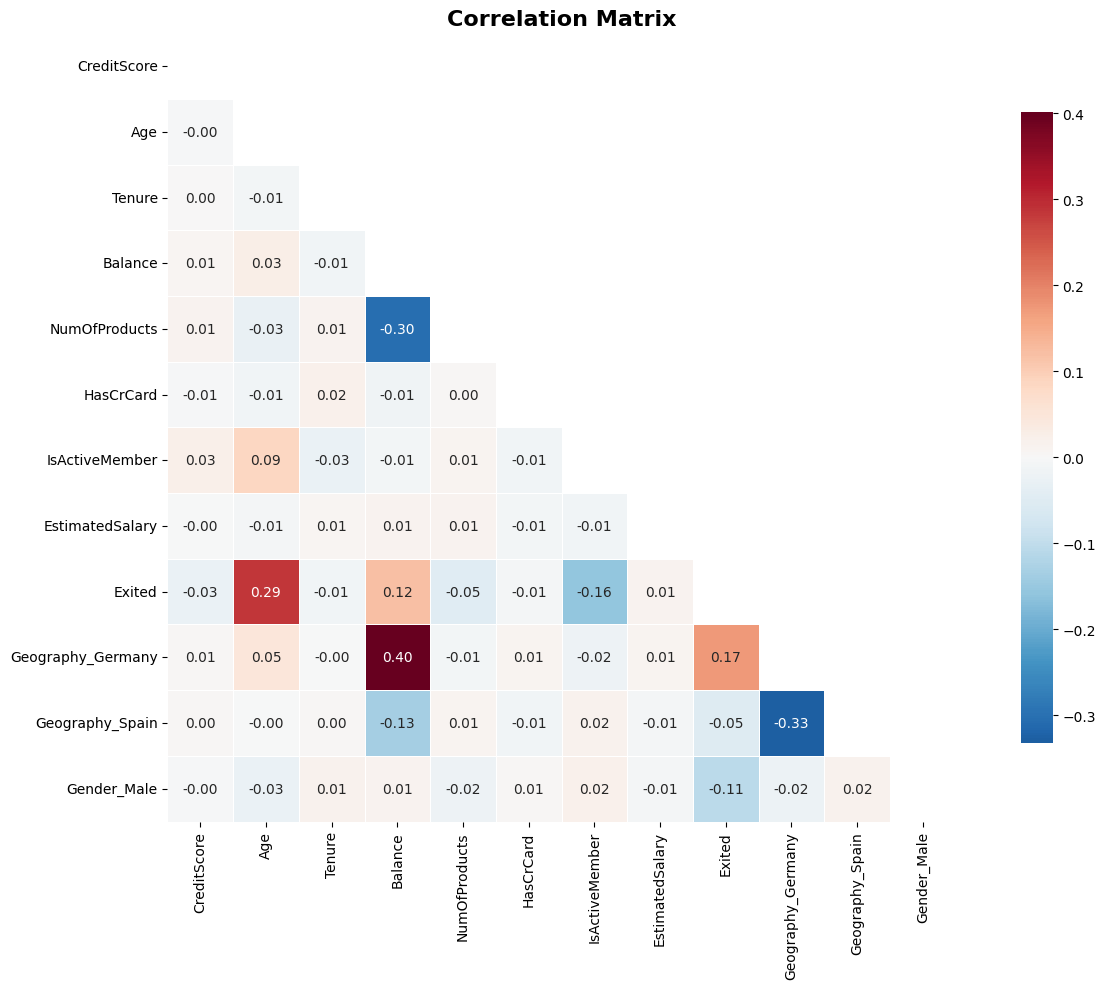


=== CORRELATION WITH CHURN (Exited) ===
Age                  0.285323
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.027094
NumOfProducts       -0.047820
Geography_Spain     -0.052667
Gender_Male         -0.106512
IsActiveMember      -0.156128
Name: Exited, dtype: float64


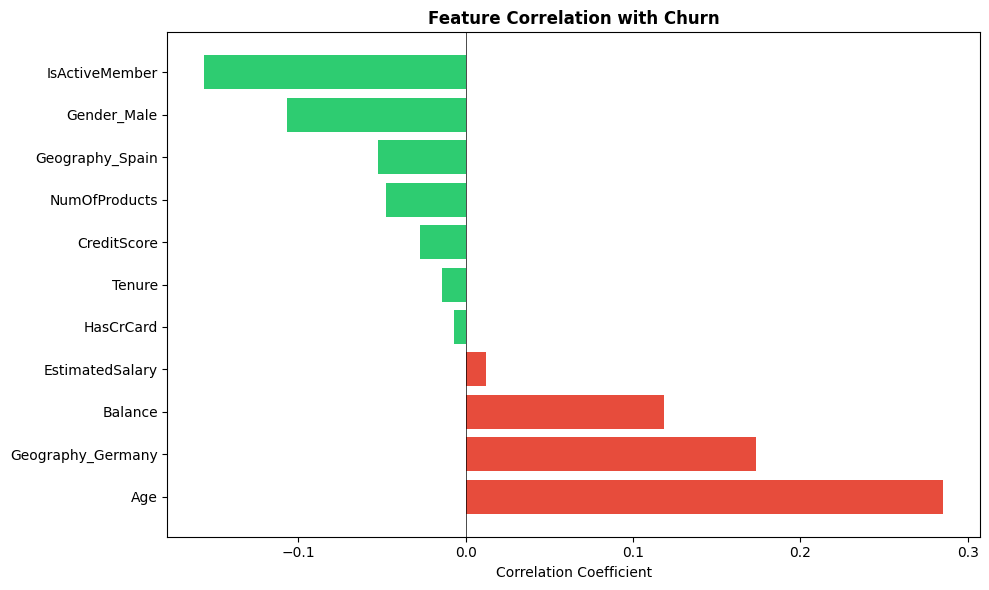

In [18]:
# ============================================================
# CORRELATION MATRIX
# ============================================================
# First encode categorical
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

plt.figure(figsize=(14, 10))
corr = df_encoded.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
print("\n=== CORRELATION WITH CHURN (Exited) ===")
target_corr = corr['Exited'].drop('Exited').sort_values(ascending=False)
print(target_corr)

# Plot
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.title('Feature Correlation with Churn', fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


Multivariate Analysis

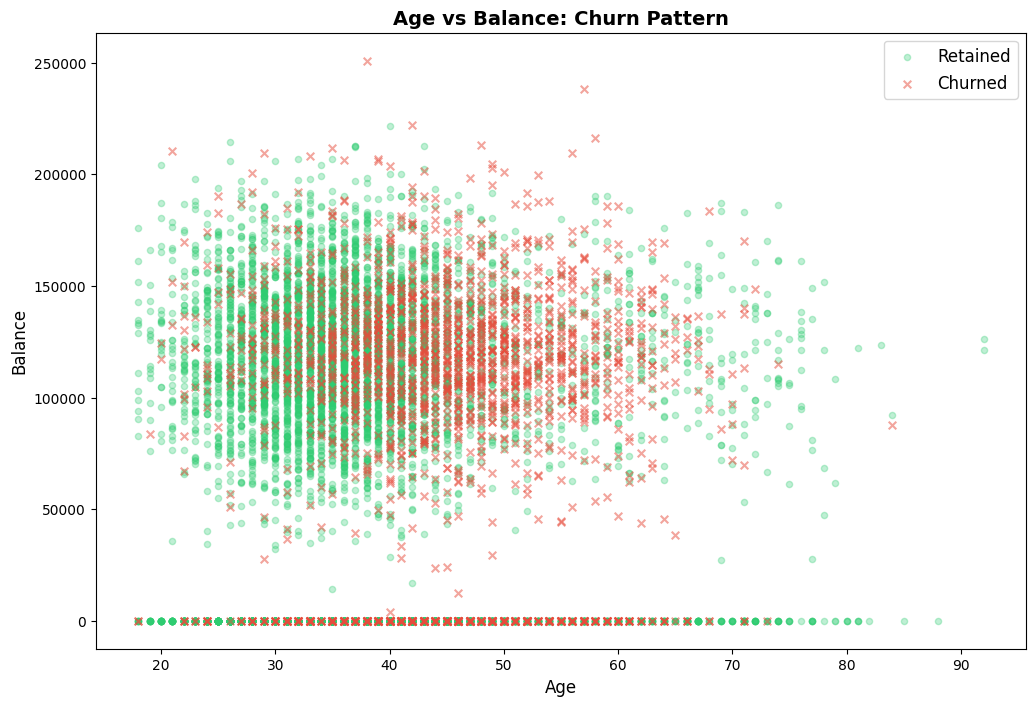

In [19]:
# AGE vs BALANCE by CHURN (SCATTER)
# ============================================================
plt.figure(figsize=(12, 8))

# Retained
plt.scatter(df[df['Exited']==0]['Age'], df[df['Exited']==0]['Balance'], 
            alpha=0.3, s=20, color='#2ecc71', label='Retained')

# Churned  
plt.scatter(df[df['Exited']==1]['Age'], df[df['Exited']==1]['Balance'], 
            alpha=0.5, s=30, color='#e74c3c', label='Churned', marker='x')

plt.xlabel('Age', fontsize=12)
plt.ylabel('Balance', fontsize=12)
plt.title('Age vs Balance: Churn Pattern', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.show()


One hot encoding two columns Geography and Gender to make everything numerical

In [20]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

In [21]:
display(df.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [22]:
X = df.drop(columns=['Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state = 1)

Applying Scaling Creating Scaler Object Using Standard Scaler Class 

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [24]:
X_train_scaled

array([[ 0.71997988,  1.25618088,  0.68308948, ..., -0.58207179,
        -0.57324462,  0.91776859],
       [-0.75327193, -0.65952721, -1.39766776, ..., -0.58207179,
        -0.57324462, -1.08959928],
       [ 0.57574543,  0.39411224, -1.39766776, ..., -0.58207179,
         1.74445599, -1.08959928],
       ...,
       [ 0.22546179,  0.58568305,  1.37667523, ..., -0.58207179,
        -0.57324462, -1.08959928],
       [ 0.13273964,  0.01097062,  1.02988235, ..., -0.58207179,
        -0.57324462, -1.08959928],
       [ 1.16298567,  0.29832684,  0.33629661, ...,  1.71800114,
        -0.57324462,  0.91776859]], shape=(7500, 11))

Applying Keras

In [25]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [26]:
#Creating Model object of Sequential

#Adding layers 

model = Sequential()

model.add(Dense(11, activation='relu', input_dim = 11))

model.add(Dense(11, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

c:\Users\Shahzain Ahmed\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [29]:
history = model.fit(X_train_scaled, y_train, epochs=15, validation_split=0.2)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7980 - loss: 0.5110 - val_accuracy: 0.7967 - val_loss: 0.4675
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7975 - loss: 0.4523 - val_accuracy: 0.7947 - val_loss: 0.4464
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8047 - loss: 0.4371 - val_accuracy: 0.8027 - val_loss: 0.4390
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8128 - loss: 0.4286 - val_accuracy: 0.8013 - val_loss: 0.4335
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8200 - loss: 0.4210 - val_accuracy: 0.8080 - val_loss: 0.4279
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8282 - loss: 0.4137 - val_accuracy: 0.8120 - val_loss: 0.4216
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8363 - loss: 0.4059 - val_accuracy: 0.8213 - val_loss: 0.4127
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8393 - loss: 0.3971 - val_accuracy: 0.

In [30]:
model.layers[0].get_weights()

[array([[ 2.82735467e-01, -3.33219945e-01, -3.58997196e-01,
         -1.33012338e-02,  2.89453149e-01,  7.95935746e-03,
          7.13821054e-02,  1.04720987e-01, -1.00729734e-01,
          2.08050489e-01, -4.28231321e-02],
        [ 9.38306689e-01,  6.43176258e-01,  1.58252612e-01,
         -7.20873415e-01, -4.23607796e-01,  2.12511078e-01,
         -2.60895997e-01, -3.64976108e-01, -1.53723344e-01,
         -3.16638023e-01,  1.85833156e-01],
        [ 3.02523136e-01,  4.00175899e-02, -4.15487289e-01,
         -3.34348619e-01,  6.32217005e-02,  2.27355838e-01,
          2.41749525e-01,  2.59055525e-01,  3.68519127e-01,
         -2.21920788e-01,  1.39110997e-01],
        [-2.60573737e-02, -2.08210975e-01, -1.39782980e-01,
         -1.64842054e-01, -2.03775331e-01,  5.49439251e-01,
          1.42776087e-01, -1.56628322e-02,  4.25504357e-01,
         -3.38815093e-01, -1.40808344e-01],
        [ 3.02452564e-01, -4.44283262e-02,  6.99512303e-01,
          1.01314545e-01,  7.54996836e-02,  

In [31]:
model.layers[1].get_weights()

[array([[-0.01196427, -0.37943938,  0.29297432,  0.32746288,  0.0059064 ,
         -0.06046713,  0.6179474 ,  0.3179395 , -0.4594112 , -0.08915512,
          0.5035986 ],
        [ 0.01107167,  0.15443633,  0.441131  ,  0.01304354, -0.21871953,
         -0.19589113,  0.095369  ,  0.51308376, -0.26487797,  0.21533293,
          0.40480873],
        [ 0.12650602, -0.18628825, -0.49726787,  0.15594049,  0.25397447,
         -0.38185513,  0.64454186, -0.55404925,  0.38526696,  0.01407312,
         -0.22465576],
        [-0.38887703,  0.500383  , -0.21224388, -0.5107614 , -0.10541943,
         -0.4775042 , -0.02915352, -0.14628838, -0.0891282 , -0.04976158,
          0.22127919],
        [ 0.5201153 , -0.01071301, -0.23964597,  0.21443832,  0.25792843,
         -0.25989154,  0.18987782, -0.28476167,  0.01372304,  0.40628085,
          0.12946883],
        [-0.56287897,  0.09514985,  0.09525756,  0.94619423, -0.5435635 ,
          0.0584911 ,  0.24616171, -0.08285872, -0.4666632 , -0.1786118

In [32]:
model.layers[2].get_weights()

[array([[-0.56186134],
        [-0.8019075 ],
        [-0.50175124],
        [ 0.4895677 ],
        [-0.6256196 ],
        [-0.7257254 ],
        [ 0.29776305],
        [-0.69099987],
        [-0.5715658 ],
        [-0.3221735 ],
        [-0.84216243]], dtype=float32),
 array([-0.05376323], dtype=float32)]

In [33]:
y_log = model.predict(X_test_scaled)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [34]:
y_log

array([[0.07268879],
       [0.11203613],
       [0.09919837],
       ...,
       [0.4051162 ],
       [0.46071145],
       [0.10600699]], shape=(2500, 1), dtype=float32)

In [35]:
y_pred = np.where(y_log > 0.5 , 1, 0)

In [36]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2500, 1))

Checking Model Accuracy

In [37]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8556

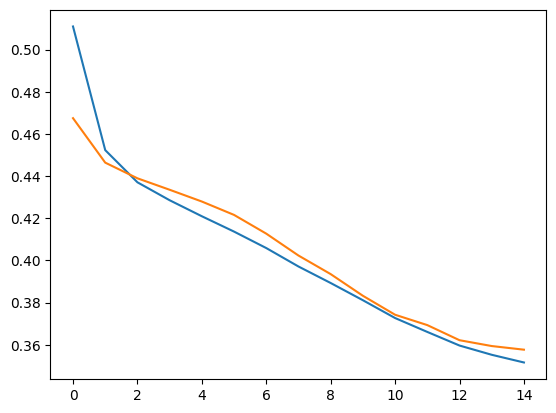

In [39]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

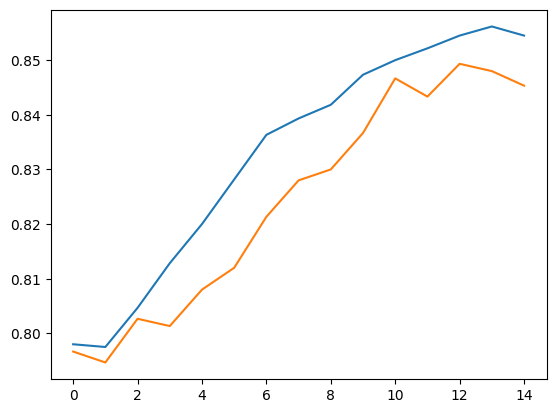

In [40]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])